# Code for generating Fig.4 & 5

## 4b

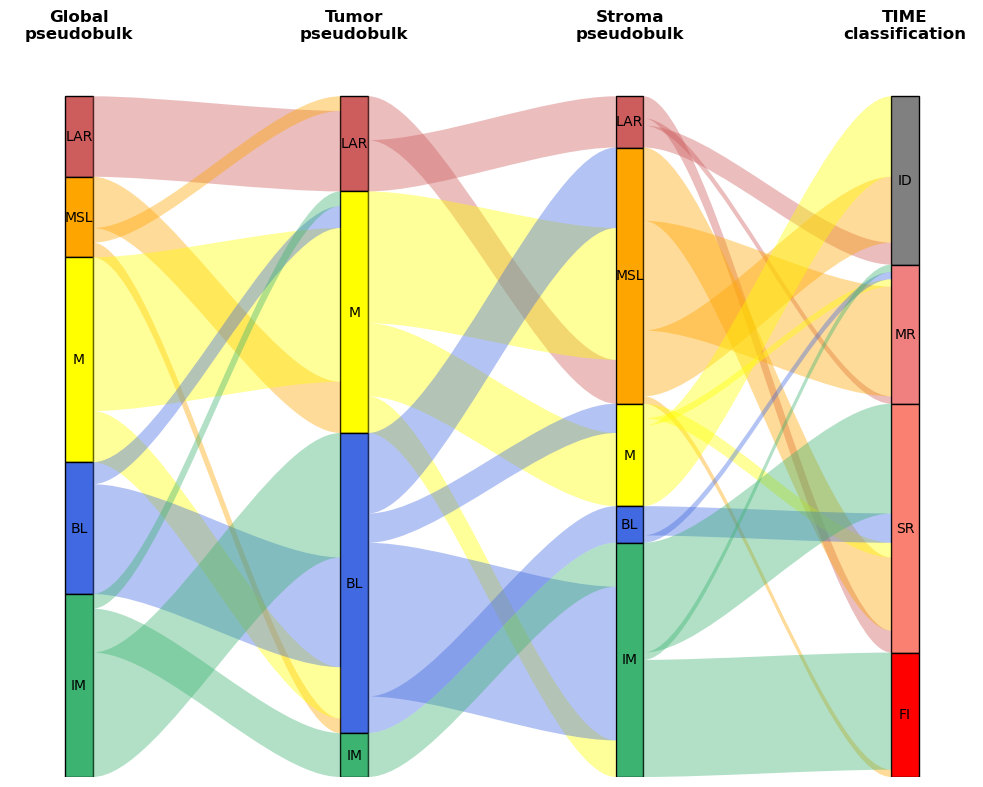

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path

# Load your mapping data
file_path = "fig4/4b.xlsx"
df = pd.read_excel(file_path)
df = df.dropna(subset=['TIME'])  # Drop missing TIME samples

# Column order
columns = ['PB', 'Tumor', 'Stroma', 'TIME']

# Color map
color_map = {
    'LAR': 'indianred',
    'MSL': 'orange',
    'M': 'yellow',
    'BL': 'royalblue',
    'IM': 'mediumseagreen',
    'ID': 'gray',
    'MR': 'lightcoral',
    'SR': 'salmon',
    'FI': 'red'
}

# Define the desired order of labels for each column
category_order_map = {
    'PB': ['LAR', 'MSL', 'M', 'BL', 'IM'],
    'Tumor': ['LAR', 'MSL', 'M', 'BL', 'IM'],
    'Stroma': ['LAR', 'MSL', 'M', 'BL', 'IM'],
    'TIME': ['ID', 'MR', 'SR', 'FI']
}

# Layout constants
x_gap = 2.0
column_x = {col: i * x_gap for i, col in enumerate(columns)}
box_width = 0.2
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')

# Scale factor
total_count = len(df)
scale = 1.0 / total_count

# Collect labels and assign block heights
label_positions = {}
block_heights = {}

for col in columns:
    label_positions[col] = {}
    block_heights[col] = {}
    y = 1.0
    ordered = [lbl for lbl in category_order_map[col] if lbl in df[col].values]
    for lbl in ordered:
        height = df[df[col] == lbl].shape[0] * scale
        label_positions[col][lbl] = (y - height, y)
        block_heights[col][lbl] = height
        rect = patches.Rectangle((column_x[col] - box_width/2, y - height), box_width, height,
                                 facecolor=color_map.get(lbl, 'lightgray'), edgecolor='black')
        ax.add_patch(rect)
        ax.text(column_x[col], y - height / 2, lbl, ha='center', va='center', fontsize=10)
        y -= height

# Draw flows
for i in range(len(columns) - 1):
    src_col = columns[i]
    tgt_col = columns[i + 1]

    # Calculate flow counts
    flow_data = df.groupby([src_col, tgt_col]).size().reset_index(name='count')
    flow_data = flow_data.sort_values(by=[src_col], key=lambda x: x.map({k: i for i, k in enumerate(category_order_map[src_col])}))

    # Track offsets within each label block
    src_offsets = {lbl: label_positions[src_col][lbl][0] for lbl in label_positions[src_col]}
    tgt_offsets = {lbl: label_positions[tgt_col][lbl][0] for lbl in label_positions[tgt_col]}

    for _, row in flow_data.iterrows():
        src_lbl, tgt_lbl = row[src_col], row[tgt_col]
        count = row['count']
        thickness = count * scale

        src_x = column_x[src_col] + box_width / 2
        tgt_x = column_x[tgt_col] - box_width / 2

        src_y0 = src_offsets[src_lbl]
        src_y1 = src_y0 + thickness
        src_offsets[src_lbl] = src_y1

        tgt_y0 = tgt_offsets[tgt_lbl]
        tgt_y1 = tgt_y0 + thickness
        tgt_offsets[tgt_lbl] = tgt_y1

        # Build curved path
        path_data = [
            (Path.MOVETO, (src_x, src_y0)),
            (Path.CURVE4, (src_x + 0.5, src_y0)),
            (Path.CURVE4, (tgt_x - 0.5, tgt_y0)),
            (Path.CURVE4, (tgt_x, tgt_y0)),

            (Path.LINETO, (tgt_x, tgt_y1)),
            (Path.CURVE4, (tgt_x - 0.5, tgt_y1)),
            (Path.CURVE4, (src_x + 0.5, src_y1)),
            (Path.CURVE4, (src_x, src_y1)),

            (Path.CLOSEPOLY, (src_x, src_y0))
        ]

        codes, verts = zip(*path_data)
        path = Path(verts, codes)
        patch = patches.PathPatch(path, facecolor=color_map.get(src_lbl, 'lightgray'), edgecolor='none', alpha=0.4)
        ax.add_patch(patch)

# Add column titles
titles = {
    'PB': 'Global\npseudobulk',
    'Tumor': 'Tumor\npseudobulk',
    'Stroma': 'Stroma\npseudobulk',
    'TIME': 'TIME\nclassification'
}
for col in columns:
    ax.text(column_x[col], 1.08, titles[col], ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlim(-0.5, x_gap * (len(columns) - 1) + 0.5)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


## 4e

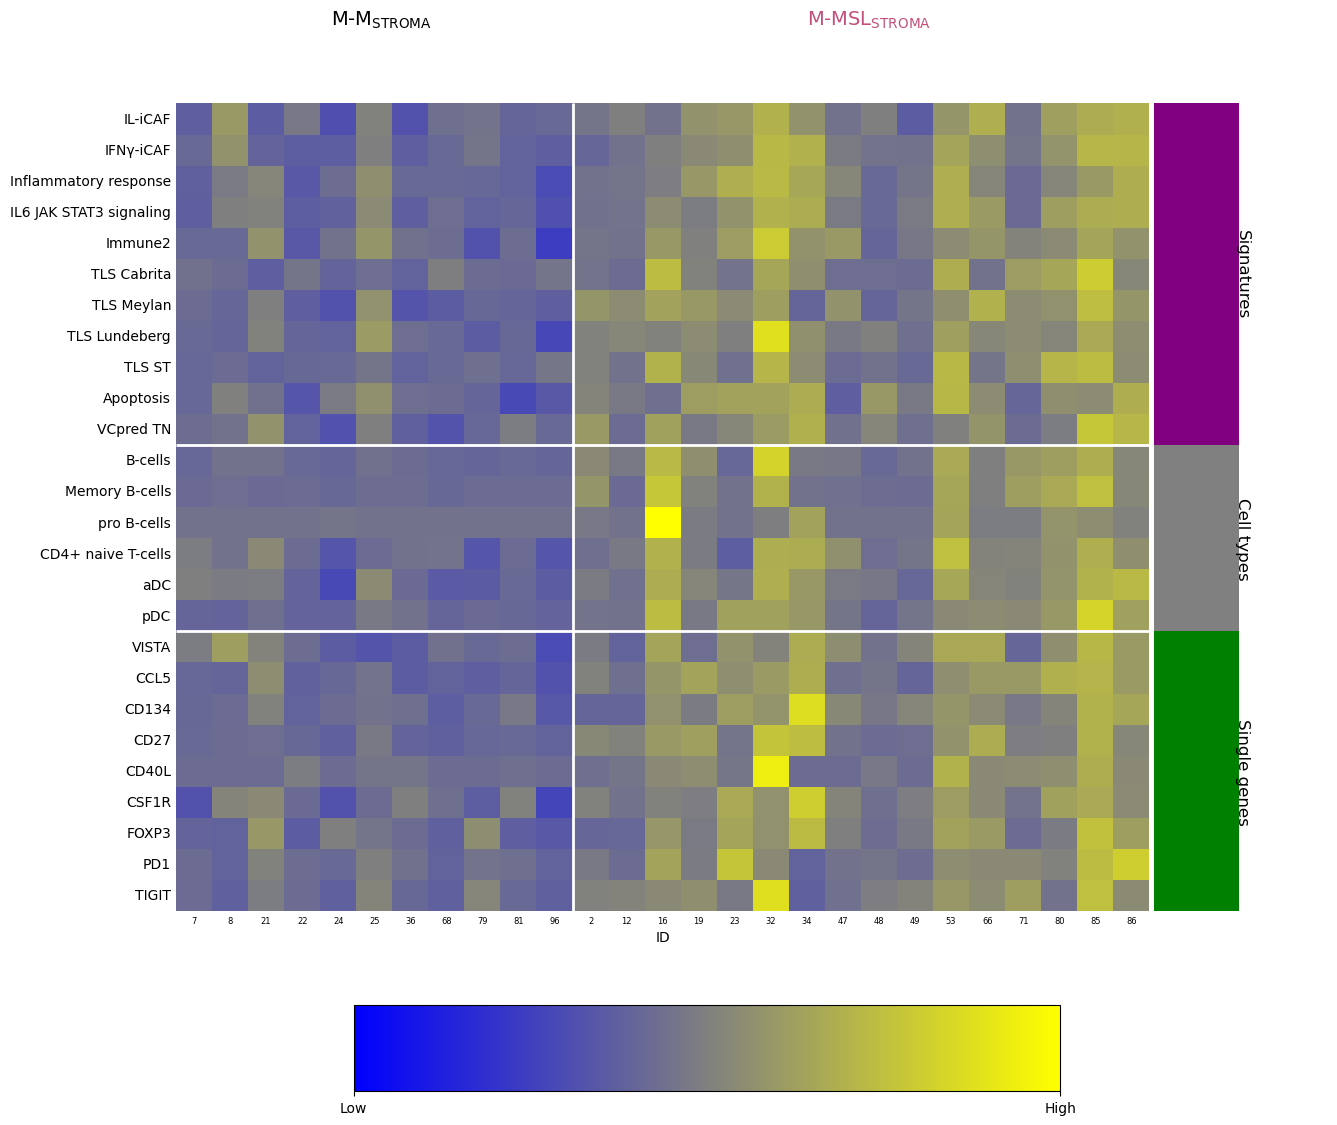

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import to_rgb
from matplotlib.colors import LinearSegmentedColormap

# Load your real Excel data
file_path = "fig4/4e.xlsx"
df_full = pd.read_excel(file_path, index_col=0)

# Extract meta and data
meta = df_full.iloc[:, :2]  # 'Stroma subtype' and 'PB subtype'
data = df_full.iloc[:, 2:]  # Actual expression data

# Your desired sample IDs
sample_ids_m = [7, 8, 21, 22, 24, 25, 36, 68, 79, 81, 96]
sample_ids_msl = [2, 12, 16, 19, 23, 32, 34, 47, 48, 49, 53, 66, 71, 80, 85, 86]
sample_ids = sample_ids_m + sample_ids_msl

# Your desired feature names
signatures = ['IL-iCAF', 'IFNγ-iCAF', 'Inflammatory response', 'IL6 JAK STAT3 signaling', 'Immune2',
              'TLS Cabrita', 'TLS Meylan', 'TLS Lundeberg', 'TLS ST', 'Apoptosis', 'VCpred TN']
cell_types = ['B-cells', 'Memory B-cells', 'pro B-cells', 'CD4+ naive T-cells', 'aDC', 'pDC']
single_genes = ['VISTA', 'CCL5', 'CD134', 'CD27', 'CD40L', 'CSF1R', 'FOXP3', 'PD1', 'TIGIT']
feature_names = signatures + cell_types + single_genes

# Transpose so samples become columns
data = data.T
data = data.loc[feature_names, sample_ids]
df_scaled = (data - data.mean(axis=1).values[:, None]) / data.std(axis=1).values[:, None]

# Layout
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(12, 14, wspace=0.05, hspace=0.05)

# Top Labels
ax_label = fig.add_subplot(gs[0, 1:-2])
ax_label.axis('off')
ax_label.text(5.5/26, 0.8, 'M-M$_{\\mathrm{STROMA}}$', ha='center', va='bottom', fontsize=14, color='black', transform=ax_label.transAxes)
ax_label.text((11+7.5)/26, 0.8, 'M-MSL$_{\\mathrm{STROMA}}$', ha='center', va='bottom', fontsize=14, color='#C34E79', transform=ax_label.transAxes)

# Heatmap
colors = ['blue', 'gray', 'yellow']
cmap = LinearSegmentedColormap.from_list('custom_blue_gray_yellow', colors, N=256)
ax_heatmap = fig.add_subplot(gs[1:10, 1:-2])
sns.heatmap(
    df_scaled,
    cmap = cmap,
    center=0,
    xticklabels=True,
    yticklabels=True,
    cbar=False,
    ax=ax_heatmap
)

# White Lines
signature_end = len(signatures)
celltype_end = signature_end + len(cell_types)
midpoint = len(sample_ids_m)

ax_heatmap.hlines(signature_end, *ax_heatmap.get_xlim(), colors='white', linewidth=2)
ax_heatmap.hlines(celltype_end, *ax_heatmap.get_xlim(), colors='white', linewidth=2)
ax_heatmap.vlines(midpoint, *ax_heatmap.get_ylim(), colors='white', linewidth=2)

# X ticks
ax_heatmap.set_xticks(np.arange(len(sample_ids)) + 0.5)
ax_heatmap.set_xticklabels(sample_ids, rotation=0, fontsize=6)
ax_heatmap.tick_params(axis='x', length=0)

# Y ticks
ax_heatmap.set_yticks(np.arange(len(feature_names)) + 0.5)
ax_heatmap.set_yticklabels(feature_names, rotation=0, fontsize=10)
ax_heatmap.tick_params(axis='y', length=0)

# Right group colorbar
ax_colors = fig.add_subplot(gs[1:10, -2])
group_colors_text = ['purple'] * len(signatures) + ['gray'] * len(cell_types) + ['green'] * len(single_genes)
group_colors_rgb = np.array([to_rgb(color) for color in group_colors_text]).reshape(len(group_colors_text), 1, 3)
ax_colors.imshow(group_colors_rgb, aspect='auto')
ax_colors.axis('off')

# Right group text
ax_grouptext = fig.add_subplot(gs[1:10, -1])
ax_grouptext.axis('off')
ax_grouptext.text(0, (len(signatures)/2)/len(feature_names), 'Signatures', rotation=270, va='center', ha='center', fontsize=12, color='black')
ax_grouptext.text(0, (len(signatures)+len(cell_types)/2)/len(feature_names), 'Cell types', rotation=270, va='center', ha='center', fontsize=12, color='black')
ax_grouptext.text(0, (len(signatures)+len(cell_types)+len(single_genes)/2)/len(feature_names), 'Single genes', rotation=270, va='center', ha='center', fontsize=12, color='black')
ax_grouptext.invert_yaxis()

# Bottom Colorbar
ax_cb = fig.add_subplot(gs[11, 3:-3])
norm = plt.Normalize(vmin=df_scaled.values.min(), vmax=df_scaled.values.max())
sm = plt.cm.ScalarMappable(cmap= cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, cax=ax_cb, orientation='horizontal')
cb.set_ticks([df_scaled.values.min(), df_scaled.values.max()])
cb.set_ticklabels(['Low', 'High'])
cb.ax.tick_params(labelsize=10)

plt.show()

## 4f

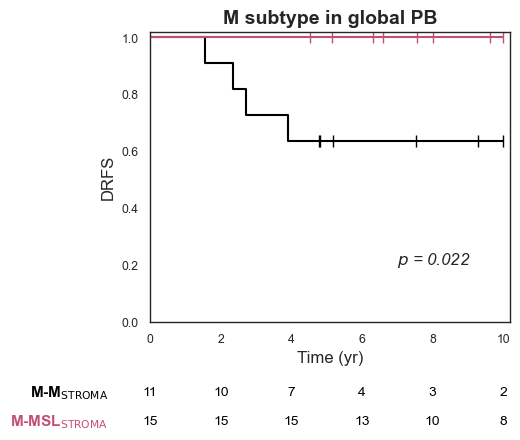

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load your data
file_path = "fig4/4f.xlsx"
df = pd.read_excel(file_path)
df = df.dropna(subset=['DRFS.time', 'DRFS.event'])

# Split groups
group1 = df[df['Class'] == 'M-Mstroma']
group2 = df[df['Class'] == 'M-MSLstroma']

# Plot setup
fig, ax = plt.subplots(figsize=(6, 5))
kmf1 = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()

kmf1.fit(group1['DRFS.time'], group1['DRFS.event'], label='M-M$_{\\mathrm{STROMA}}$')
kmf2.fit(group2['DRFS.time'], group2['DRFS.event'], label='M-MSL$_{\\mathrm{STROMA}}$')

kmf1.plot_survival_function(ax=ax, ci_show=False, show_censors=True,
                            censor_styles={'marker': '|', 'ms': 8}, color='black', linewidth=1.5)
kmf2.plot_survival_function(ax=ax, ci_show=False, show_censors=True,
                            censor_styles={'marker': '|', 'ms': 8}, color='#C34E79', linewidth=1.5)

# Axes formatting
ax.set_xlabel('Time (yr)', fontsize=12)
ax.set_ylabel('DRFS', fontsize=12)
ax.set_xlim(0, 10.2)
ax.set_ylim(0, 1.02)
ax.set_title('M subtype in global PB', fontsize=14, weight='bold')
ax.legend().remove()

# Permutation log-rank test
T = pd.concat([group1['DRFS.time'], group2['DRFS.time']])
E = pd.concat([group1['DRFS.event'], group2['DRFS.event']])
labels = np.array([1]*len(group1) + [0]*len(group2))

# Observed stat
obs = logrank_test(T[labels == 1], T[labels == 0], E[labels == 1], E[labels == 0])
obs_stat = obs.test_statistic

# Permutation
n_perms = 1000
perm_stats = []
for _ in range(n_perms):
    perm = np.random.permutation(labels)
    stat = logrank_test(T[perm == 1], T[perm == 0], E[perm == 1], E[perm == 0]).test_statistic
    perm_stats.append(stat)

p_perm = np.mean(np.array(perm_stats) >= obs_stat)

# Add permutation p-value to plot
ax.text(7, 0.2, f'$p$ = {p_perm:.3f}', fontsize=12, style='italic')

# Number at risk table
times = np.arange(0, 11, 2)
at_risk_1 = [np.sum(group1['DRFS.time'] >= t) for t in times]
at_risk_2 = [np.sum(group2['DRFS.time'] >= t) for t in times]

# Below plot
for i, (n1, n2) in enumerate(zip(at_risk_1, at_risk_2)):
    xpos = times[i]
    # numbers stay centered under time points
    ax.text(xpos, -0.25, str(n1), ha='center', va='center', fontsize=10, color='black')
    ax.text(xpos, -0.35, str(n2), ha='center', va='center', fontsize=10, color='black')

# Then separately plot the group labels at the far left
ax.text(-1.2, -0.25, 'M-M$_{\\mathrm{STROMA}}$', ha='right', va='center', fontsize=11, color='black', weight='bold')
ax.text(-1.2, -0.35, 'M-MSL$_{\\mathrm{STROMA}}$', ha='right', va='center', fontsize=11, color='#C34E79', weight='bold')

# Adjust layout to make room
plt.subplots_adjust(left=0.3, bottom=0.3)
plt.show()

## 5b

C:\Users\erinc\AppData\Local\Temp\ipykernel_25548\1304532158.py:48: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


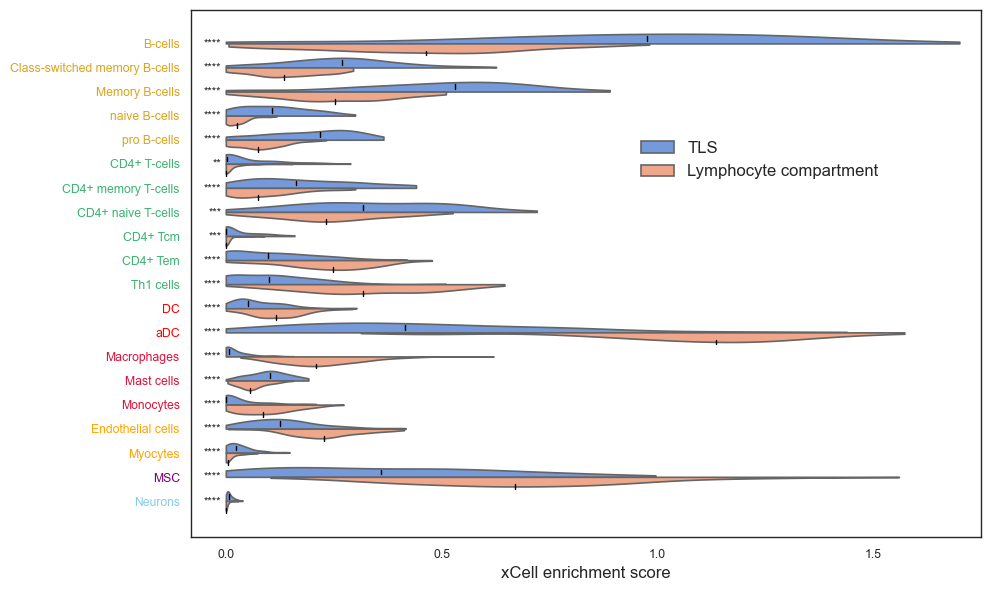

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# Load the data
df = pd.read_excel("fig5/5b.xlsx")

# Define ordered cell types and label colors
ordered_cell_types = [
    "B-cells", "Class-switched memory B-cells", "Memory B-cells", "naive B-cells", "pro B-cells",
    "CD4+ T-cells", "CD4+ memory T-cells", "CD4+ naive T-cells", "CD4+ Tcm", "CD4+ Tem", "Th1 cells",
    "DC", "aDC", "Macrophages", "Mast cells", "Monocytes", "Endothelial cells", "Myocytes", "MSC", "Neurons"
]

label_colors = [
    "goldenrod", "goldenrod", "goldenrod", "goldenrod", "goldenrod",
    "mediumseagreen", "mediumseagreen", "mediumseagreen", "mediumseagreen", "mediumseagreen", "mediumseagreen",
    "red", "red", "crimson", "crimson", "crimson",
    "orange", "orange", "purple", "skyblue"
]

# Statistical testing and reshape
plot_data = []
p_values = []

for cell_type in ordered_cell_types:
    tls_vals = df[df['Compartment'] == 'TLS'][cell_type].values
    lymph_vals = df[df['Compartment'] == 'Lymphocytes'][cell_type].values
    _, p = ranksums(tls_vals, lymph_vals)
    p_values.append(p)

    for val in tls_vals:
        plot_data.append({'Cell Type': cell_type, 'Compartment': 'TLS', 'Score': val})
    for val in lymph_vals:
        plot_data.append({'Cell Type': cell_type, 'Compartment': 'Lymphocyte compartment', 'Score': val})

# FDR correction
_, fdr_corrected_p, _, _ = multipletests(p_values, method='fdr_bh')

# Create DataFrame
plot_df = pd.DataFrame(plot_data)
plot_df["Cell Type"] = pd.Categorical(plot_df["Cell Type"], categories=ordered_cell_types, ordered=True)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=plot_df, x="Score", y="Cell Type", hue="Compartment",
    palette={"TLS": "cornflowerblue", "Lymphocyte compartment": "lightsalmon"},
    split=True, inner=None, linewidth=1.2, scale="width", cut=0)

# Add significance asterisks
for i, p in enumerate(fdr_corrected_p):
    if p < 0.05:
        if p < 0.0001:
            stars = "****"
        elif p < 0.001:
            stars = "***"
        elif p < 0.01:
            stars = "**"
        else:
            stars = "*"
        plt.text(-0.01, i, stars, va='center', ha='right', fontsize=8)

# Annotate median lines
for i, cell_type in enumerate(ordered_cell_types):
    for j, compartment in enumerate(['TLS', 'Lymphocyte compartment']):
        median_val = plot_df[(plot_df['Cell Type'] == cell_type) & (plot_df['Compartment'] == compartment)]['Score'].median()
        ax.plot([median_val, median_val], [i - 0.3 + j*0.6, i - 0.1 + j*0.6], color='black', linewidth=1)

# Color the y-axis tick labels
y_labels = ax.get_yticklabels()
for tick_label, color in zip(y_labels, label_colors):
    tick_label.set_color(color)

# Set x-axis range and ticks to match example
ax.set_xlim(-0.08, 1.75)
ax.set_xticks([0.0, 0.5, 1.0, 1.5])
plt.xlabel("xCell enrichment score", fontsize=12)
plt.ylabel("")
plt.title("")
plt.legend(
    title=None,
    loc='lower left',
    bbox_to_anchor=(0.55, 0.65),  # adjust to fine-tune position
    frameon=False,
    fontsize=12
)
plt.tight_layout()
plt.show()

## 5c

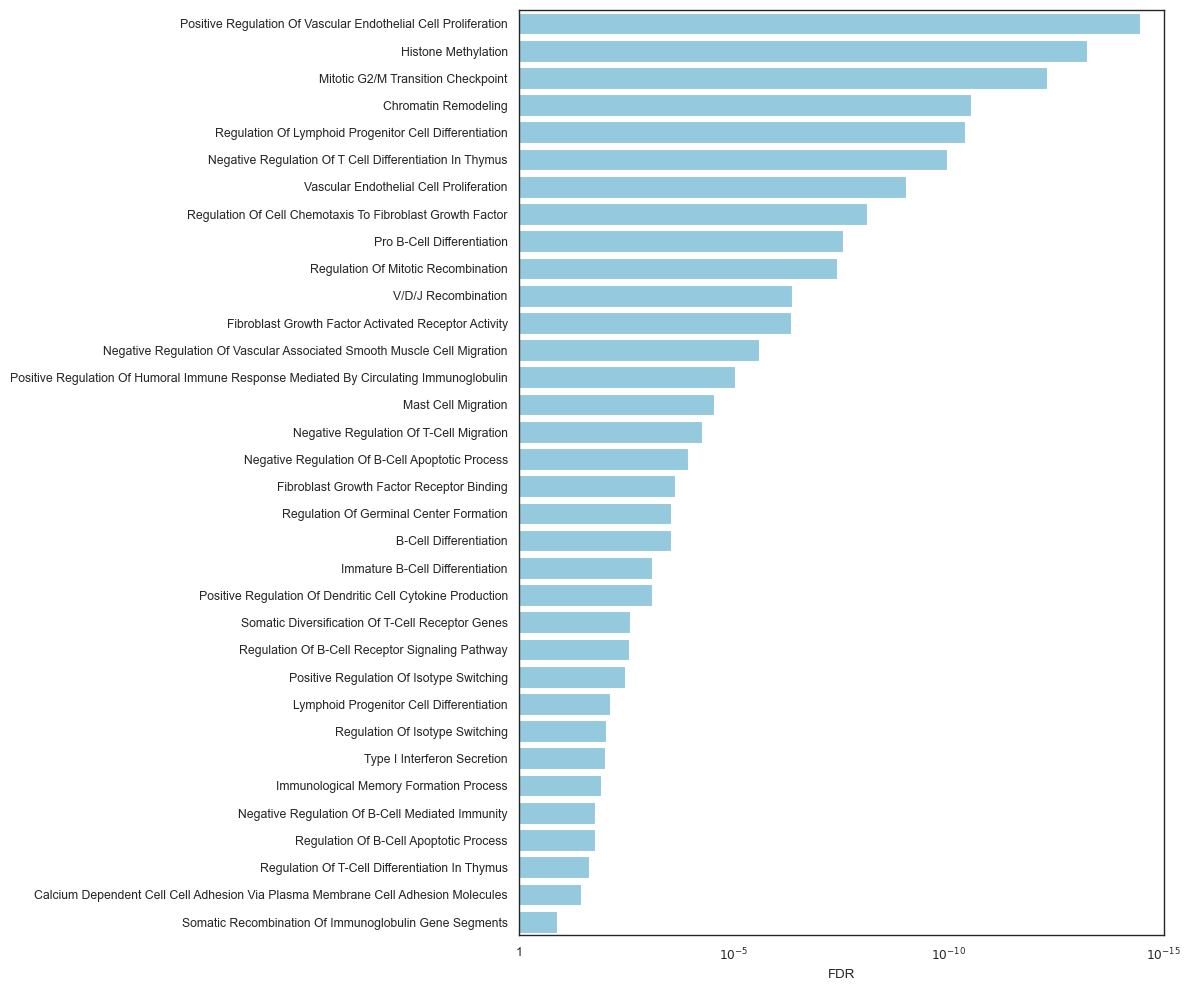

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_excel("./selected_GO.xlsx")
df["GO"] = df["GO"].str.replace("GO_", "", regex=False).str.replace("_", " ").str.lower().str.title()

# Calculate 1/FDR for bar length (so bars grow with significance)
df["Bar Length"] = 1 / df["FDR TLS > Lymphocyte"]

# Sort by FDR
df_sorted = df.sort_values("FDR TLS > Lymphocyte", ascending=True)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(data=df_sorted, y="GO", x="Bar Length", color="skyblue")

# Set x-axis to log scale and inverted direction
plt.xscale("log")
plt.xlim(1, 1e15) 
plt.xlabel("FDR")
plt.ylabel("")
plt.xticks([1, 1e5, 1e10, 1e15], ["1", r"$10^{-5}$", r"$10^{-10}$", r"$10^{-15}$"])  # Custom tick labels
plt.tight_layout()
plt.show()

## 5f

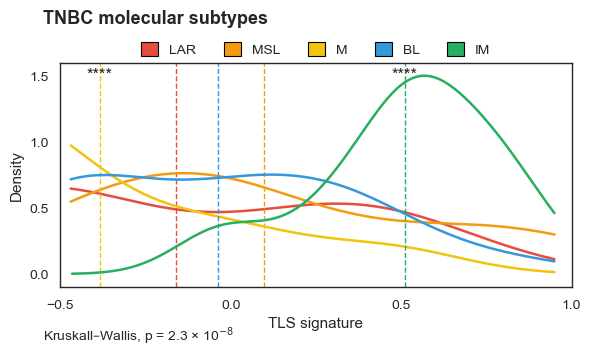

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import kruskal, ranksums
from statsmodels.stats.multitest import multipletests

# Load the data
df = pd.read_excel("fig5/5f.xlsx")
plot_df = df[['TLS ST signature', 'Subtype']].dropna()

# Define subtype colors
subtype_colors = {
    'LAR': '#E74C3C',       # red
    'MSL': '#F39C12',       # orange
    'M': '#F1C40F',         # yellow
    'BL': '#3498DB',        # blue
    'IM': '#27AE60'         # green
}

# Kruskal–Wallis test across all subtypes
groups = [plot_df[plot_df['Subtype'] == subtype]['TLS ST signature'] for subtype in subtype_colors]
kw_stat, kw_p = kruskal(*groups)

# Wilcoxon rank-sum tests: each subtype vs. all others
p_vals = []
for subtype in subtype_colors:
    this_group = plot_df[plot_df['Subtype'] == subtype]['TLS ST signature']
    other_group = plot_df[plot_df['Subtype'] != subtype]['TLS ST signature']
    stat, p = ranksums(this_group, other_group)
    p_vals.append(p)

# FDR correction
_, fdr_vals, _, _ = multipletests(p_vals, method='fdr_bh')

# Significance levels
def get_star(fdr):
    if fdr < 0.0001:
        return '****'
    elif 0.0001 <= fdr and fdr < 0.001:
        return '***'
    elif 0.001 <= fdr and fdr < 0.01:
        return '**'
    elif 0.01 <= fdr and fdr < 0.05:
        return '*'
    else:
        return ''

# Format p-value as a × 10⁻⁸
def format_pval(p):
    exponent = int(f"{p:.1e}".split('e')[1])
    base = float(f"{p:.1e}".split('e')[0])
    return f"{base:.1f} × 10$^{{{exponent}}}$"

# Start plotting
plt.figure(figsize=(6, 4))
sns.set(style="white", context="paper")

# Plot KDE and means
for i, (subtype, color) in enumerate(subtype_colors.items()):
    subset = plot_df[plot_df['Subtype'] == subtype]
    sns.kdeplot(data=subset, x='TLS ST signature', color=color, linewidth=1.8, clip=(-0.47, 0.95))
    mean_val = subset['TLS ST signature'].mean()
    plt.axvline(mean_val, color=color, linestyle='--', linewidth=1)
    
    star = get_star(fdr_vals[i])
    if star:
        plt.text(mean_val, 1.48, star, fontsize=12, ha='center')

# Custom legend using patches
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=label)
    for label, color in subtype_colors.items()
]
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.15),
           ncol=5, frameon=False, fontsize=10, handleheight=1.2, handlelength=1.2)

# Labels and formatting
plt.xlim(-0.5, 1.0)
plt.ylim(-0.1, 1.6)
plt.xticks([-0.5, 0.0, 0.5, 1.0], fontsize=10)
plt.yticks([0.0, 0.5, 1.0, 1.5], fontsize=10)
plt.xlabel("TLS signature", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.text(-0.55, 1.9, "TNBC molecular subtypes", fontsize=13, weight='bold')
plt.text(-0.55, -0.5, f"Kruskall–Wallis, p = {format_pval(kw_p)}", fontsize=10)
plt.tight_layout()
plt.show()

## 5g

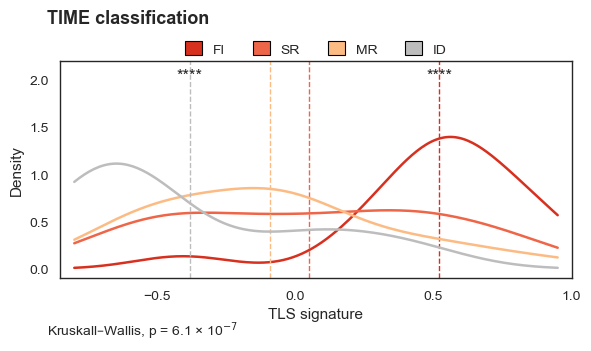

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import kruskal, ranksums
from statsmodels.stats.multitest import multipletests

# Load the data
df = pd.read_excel("fig5/5g.xlsx")
plot_df = df[['TLS ST signature', 'TIME']].dropna()

# Define colors for TIME classifications
time_colors = {
    'FI': '#D7301F',  # strong red
    'SR': '#EF6548',  # orange-red
    'MR': '#FDBB84',  # light brown
    'ID': '#BDBDBD'   # grey
}

# Run Kruskal–Wallis test
groups = [plot_df[plot_df['TIME'] == time]['TLS ST signature'] for time in time_colors]
kw_stat, kw_p = kruskal(*groups)

# Wilcoxon rank-sum tests: each subtype vs. all others
p_vals = []
for time in time_colors:
    this_group = plot_df[plot_df['TIME'] == time]['TLS ST signature']
    other_group = plot_df[plot_df['TIME'] != time]['TLS ST signature']
    stat, p = ranksums(this_group, other_group)
    p_vals.append(p)

# FDR correction
_, fdr_vals, _, _ = multipletests(p_vals, method='fdr_bh')

# Significance levels
def get_star(fdr):
    if fdr < 0.0001:
        return '****'
    elif 0.0001 <= fdr and fdr < 0.001:
        return '***'
    elif 0.001 <= fdr and fdr < 0.01:
        return '**'
    elif 0.01 <= fdr and fdr < 0.05:
        return '*'
    else:
        return ''

# Format p-value as a × 10⁻⁸
def format_pval(p):
    exponent = int(f"{p:.1e}".split('e')[1])
    base = float(f"{p:.1e}".split('e')[0])
    return f"{base:.1f} × 10$^{{{exponent}}}$"

# Start plotting
plt.figure(figsize=(6, 4))
sns.set(style="white", context="paper")

# Plot KDE and vertical means
for i, (time_class, color) in enumerate(time_colors.items()):
    subset = plot_df[plot_df['TIME'] == time_class]
    sns.kdeplot(data=subset, x='TLS ST signature', color=color, linewidth=1.8, clip=(-0.8, 0.95))
    mean_val = subset['TLS ST signature'].mean()
    plt.axvline(mean_val, color=color, linestyle='--', linewidth=1)

    star = get_star(fdr_vals[i])
    if star:
        plt.text(mean_val, 2, star, fontsize=12, ha='center')

# Custom legend using square patches
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=label)
    for label, color in time_colors.items()
]
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.15),
    ncol=4, frameon=False, fontsize=10, handleheight=1.2, handlelength=1.2)

# Axes and ticks
plt.xlim(-0.85, 1)
plt.ylim(-0.1, 2.2)
plt.xticks([-0.5, 0.0, 0.5, 1.0], fontsize=10)
plt.yticks([0.0, 0.5, 1.0, 1.5, 2.0], fontsize=10)
plt.xlabel("TLS signature", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.text(-0.9, 2.6, "TIME classification", fontsize=13, weight='bold')
plt.text(-0.9, -0.7, f"Kruskall–Wallis, p = {format_pval(kw_p)}", fontsize=10)
plt.tight_layout()
plt.show()